In [90]:
from rectpack import newPacker
from rectpack import PackingMode
from rectpack.guillotine import GuillotineBlsfSas


rectangles = [
    (60.3, 40.3), 
    (20.4, 35.2), 
    (123.4, 142.5), 
    (200, 100), 
    (100, 200),
    (100, 100),
    (20, 20),
    (400, 400),
    (20, 21),
    (30, 35)
    ]
bins = [(300.24, 450.36), (1e10, 1e10)]

packer = newPacker(mode=PackingMode.Online,
                   pack_algo=GuillotineBlsfSas)

In [91]:
packer.add_bin(*bins[0])

for rid, rect in enumerate(rectangles):
    packer.add_rect(*rect, rid=rid)
    print(rid, packer.validate_packing())


0 None
1 None
2 None
3 None
4 None
5 None
6 None
7 None
8 None
9 None


In [92]:
# if .rect_list() returns the same list of rects, 
# then packing results in failure.

In [93]:
packer.rect_list()

[(0, 0, 0, 40.3, 60.3, 0),
 (0, 40.3, 0, 35.2, 20.4, 1),
 (0, 0, 60.3, 123.4, 142.5, 2),
 (0, 0, 202.8, 200, 100, 3),
 (0, 200, 202.8, 100, 200, 4),
 (0, 123.4, 60.3, 100, 100, 5),
 (0, 40.3, 20.4, 20, 20, 6),
 (0, 123.4, 160.3, 21, 20, 8),
 (0, 144.4, 160.3, 35, 30, 9)]

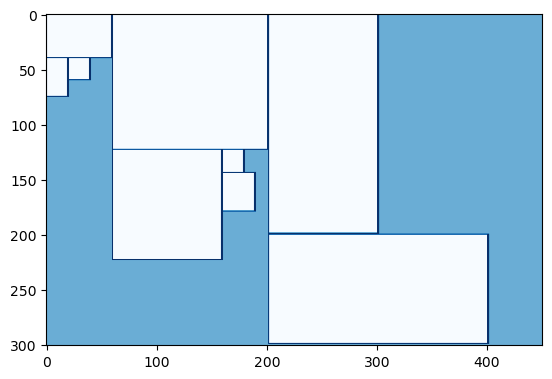

In [94]:
# discretization to 224x224 grid

import torch
import matplotlib.pyplot as plt
from math import floor, ceil

grid = torch.zeros(size=tuple(map(ceil, 
                                  bins[0])))

for (c, x, y, w, h, id) in packer.rect_list():
    grid[floor(x):ceil(x+w), floor(y):ceil(y+h)] = 1
    grid[floor(x+1):ceil(x+w-1), floor(y+1):floor(y+h-1)] = -1

plt.imshow(grid, cmap="Blues")

In [42]:
import math

math.floor(1.0), math.ceil(1.0)

(1, 1)